In [1]:
!pip install -q earthengine-api geemap folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 63.9 MB/s eta 0:00:00


In [2]:
from google.colab import drive, userdata
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
import os
import json
import random
import requests
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import folium
import ee
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split

In [4]:
ee.Authenticate()
ee.Initialize(project="wildfire-gee-project-495622")

In [7]:
BASE_DIR = "/content/drive/MyDrive/wildfire_prediction"
PROJECT_DIR = os.path.join(BASE_DIR, "sentinel2_firms_tf_lora")
RAW_DIR = os.path.join(PROJECT_DIR, "raw")
TILE_DIR = os.path.join(PROJECT_DIR, "tiles")
OUTPUT_DIR = os.path.join(PROJECT_DIR, "outputs")
MODEL_DIR = os.path.join(PROJECT_DIR, "model")

for d in [PROJECT_DIR, RAW_DIR, TILE_DIR, OUTPUT_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)

FIRMS_MAP_KEY = userdata.get("FIRMS_MAP_KEY")
HF_TOKEN = userdata.get("HF_TOKEN")

WEST = -124.5
SOUTH = 32.4
EAST = -114.0
NORTH = 42.1

START_DATE = "2021-07-01"
END_DATE = "2021-10-31"

FIRMS_SOURCE = "VIIRS_SNPP_SP"
DAY_RANGE = 5

MAX_FIRE_SAMPLES = 300
MAX_NORMAL_SAMPLES = 300

PATCH_SIZE_METERS = 2500
CLOUD_MAX = 40
IMG_SIZE = 224
BATCH_SIZE = 16
SEED = 42

random.seed(SEED)
tf.random.set_seed(SEED)

print("FIRMS_MAP_KEY loaded:", FIRMS_MAP_KEY is not None)
print("HF_TOKEN loaded:", HF_TOKEN is not None)
print("TensorFlow:", tf.__version__)

FIRMS_MAP_KEY loaded: True
HF_TOKEN loaded: True
TensorFlow: 2.20.0


In [8]:
def download_firms():
    dates = pd.date_range(START_DATE, END_DATE, freq=f"{DAY_RANGE}D")
    frames = []
    area = f"{WEST},{SOUTH},{EAST},{NORTH}"

    for date in dates:
        url = f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/{FIRMS_MAP_KEY}/{FIRMS_SOURCE}/{area}/{DAY_RANGE}/{date.strftime('%Y-%m-%d')}"
        r = requests.get(url, timeout=120)
        print(date.strftime("%Y-%m-%d"), r.status_code, r.text[:100])

        if r.status_code == 200 and "latitude" in r.text and len(r.text.splitlines()) > 1:
            path = os.path.join(RAW_DIR, f"firms_{date.strftime('%Y%m%d')}.csv")
            with open(path, "w") as f:
                f.write(r.text)
            df = pd.read_csv(path)
            if len(df) > 0:
                frames.append(df)

    if len(frames) == 0:
        raise RuntimeError("No FIRMS fire detections downloaded.")

    df = pd.concat(frames, ignore_index=True)
    df = df.drop_duplicates()
    df = df.rename(columns={"latitude": "lat", "longitude": "lon"})
    df = df[(df["lon"] >= WEST) & (df["lon"] <= EAST) & (df["lat"] >= SOUTH) & (df["lat"] <= NORTH)]
    df["date"] = pd.to_datetime(df["acq_date"]).dt.strftime("%Y-%m-%d")

    if "confidence" in df.columns:
        numeric_conf = pd.to_numeric(df["confidence"], errors="coerce")
        text_conf = df["confidence"].astype(str).str.lower()
        df = df[text_conf.isin(["n", "h", "nominal", "high"]) | numeric_conf.fillna(0).ge(70)]

    df.to_csv(os.path.join(RAW_DIR, "firms_fire_points.csv"), index=False)
    return df

In [9]:
fire_df = download_firms()
fire_df.head(), fire_df.shape

2021-07-01 200 latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,b
2021-07-06 200 latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,b
2021-07-11 200 latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,b
2021-07-16 200 latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,b
2021-07-21 200 latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,b
2021-07-26 200 latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,b
2021-07-31 200 latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,b
2021-08-05 200 latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,b
2021-08-10 200 latitude,longitude,bright_ti4,scan,track,acq_date,acq_tim

(        lat        lon  bright_ti4  scan  track    acq_date  acq_time  \
 0  40.82239 -114.25349      310.21  0.53   0.42  2021-07-01       954   
 1  37.90437 -119.66807      297.48  0.39   0.36  2021-07-01       955   
 2  39.62041 -119.26482      301.29  0.39   0.36  2021-07-01       955   
 3  39.91562 -120.37296      319.25  0.38   0.36  2021-07-01       955   
 4  39.91632 -120.37740      312.00  0.38   0.36  2021-07-01       955   
 
   satellite instrument confidence  version  bright_ti5   frp daynight  type  \
 0         N      VIIRS          n        2      284.76  1.98        N     2   
 1         N      VIIRS          n        2      283.86  0.73        N     0   
 2         N      VIIRS          n        2      290.04  0.72        N     2   
 3         N      VIIRS          n        2      289.09  2.67        N     0   
 4         N      VIIRS          n        2      289.48  2.13        N     0   
 
          date  
 0  2021-07-01  
 1  2021-07-01  
 2  2021-07-01  
 3  

In [10]:
def make_samples(fire_df):
    fire = fire_df[["lat", "lon", "date"]].dropna().copy()
    fire["label"] = "fire"
    fire = fire.sample(min(MAX_FIRE_SAMPLES, len(fire)), random_state=SEED)

    normal_rows = []
    fire_points = fire[["lat", "lon"]].values.tolist()

    attempts = 0
    while len(normal_rows) < MAX_NORMAL_SAMPLES and attempts < MAX_NORMAL_SAMPLES * 200:
        attempts += 1
        lat = random.uniform(SOUTH, NORTH)
        lon = random.uniform(WEST, EAST)
        too_close = False

        for flat, flon in fire_points:
            if ((flat - lat) ** 2 + (flon - lon) ** 2) ** 0.5 < 0.25:
                too_close = True
                break

        if not too_close:
            date = random.choice(pd.date_range(START_DATE, END_DATE).strftime("%Y-%m-%d").tolist())
            normal_rows.append({"lat": lat, "lon": lon, "date": date, "label": "normal"})

    normal = pd.DataFrame(normal_rows)
    samples = pd.concat([fire, normal], ignore_index=True)
    samples = samples.sample(frac=1, random_state=SEED).reset_index(drop=True)
    samples["sample_id"] = [f"sample_{i:05d}" for i in range(len(samples))]
    samples.to_csv(os.path.join(PROJECT_DIR, "samples.csv"), index=False)
    return samples

In [11]:
samples = make_samples(fire_df)
samples["label"].value_counts()

,count
label,
fire,300
normal,300


In [12]:
def get_sentinel_url(lat, lon, date):
    point = ee.Geometry.Point([float(lon), float(lat)])
    start = ee.Date(date).advance(-7, "day")
    end = ee.Date(date).advance(7, "day")

    collection = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(point)
        .filterDate(start, end)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", CLOUD_MAX))
        .sort("CLOUDY_PIXEL_PERCENTAGE")
    )

    image = ee.Image(collection.first()).select(["B4", "B3", "B2"])
    image = image.visualize(min=0, max=3000)
    region = point.buffer(PATCH_SIZE_METERS / 2).bounds()

    return image.getThumbURL({
        "region": region,
        "dimensions": f"{IMG_SIZE}x{IMG_SIZE}",
        "format": "png"
    })

In [13]:
def download_tiles(samples):
    rows = []

    for _, row in tqdm(samples.iterrows(), total=len(samples)):
        label_dir = os.path.join(TILE_DIR, row["label"])
        os.makedirs(label_dir, exist_ok=True)

        image_path = os.path.join(label_dir, f"{row['sample_id']}.png")

        if not os.path.exists(image_path):
            try:
                url = get_sentinel_url(row["lat"], row["lon"], row["date"])
                r = requests.get(url, timeout=120)

                if r.status_code == 200 and len(r.content) > 1000:
                    with open(image_path, "wb") as f:
                        f.write(r.content)

                    img = Image.open(image_path).convert("RGB")
                    arr = tf.cast(tf.convert_to_tensor(img), tf.float32)

                    if tf.math.reduce_std(arr).numpy() < 2:
                        os.remove(image_path)
                        continue
                else:
                    continue
            except Exception:
                continue

        rows.append({
            "image": image_path,
            "label": row["label"],
            "lat": row["lat"],
            "lon": row["lon"],
            "date": row["date"],
            "sample_id": row["sample_id"]
        })

    df = pd.DataFrame(rows)
    df.to_csv(os.path.join(PROJECT_DIR, "tile_metadata.csv"), index=False)
    return df

In [14]:
tile_df = download_tiles(samples)
tile_df["label"].value_counts(), tile_df.shape

100%|██████████| 600/600 [14:46<00:00,  1.48s/it]


(label
 fire      276
 normal    247
 Name: count, dtype: int64,
 (523, 6))

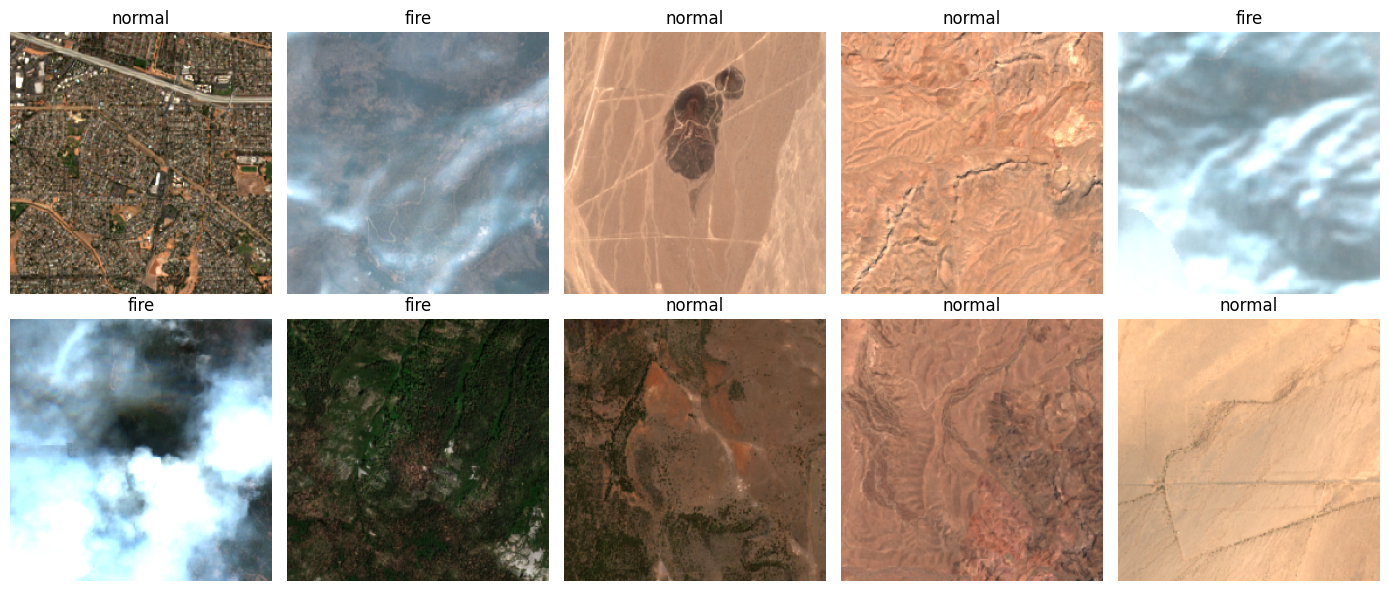

In [15]:
preview = tile_df.sample(min(10, len(tile_df)), random_state=SEED).reset_index(drop=True)

plt.figure(figsize=(14, 6))
for i, row in preview.iterrows():
    plt.subplot(2, 5, i + 1)
    plt.imshow(Image.open(row["image"]).convert("RGB"))
    plt.title(row["label"])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
label_map = {"normal": 0, "fire": 1}
tile_df["label_id"] = tile_df["label"].map(label_map)

train_df, test_df = train_test_split(
    tile_df,
    test_size=0.2,
    stratify=tile_df["label_id"],
    random_state=SEED
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["label_id"],
    random_state=SEED
)

train_df.to_csv(os.path.join(PROJECT_DIR, "train_metadata.csv"), index=False)
val_df.to_csv(os.path.join(PROJECT_DIR, "val_metadata.csv"), index=False)
test_df.to_csv(os.path.join(PROJECT_DIR, "test_metadata.csv"), index=False)

len(train_df), len(val_df), len(test_df)

(334, 84, 105)

In [17]:
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.keras.applications.efficientnet_v2.preprocess_input(img)
    return img, label

def make_tf_dataset(df, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((df["image"].values, df["label_id"].values))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(1000, seed=SEED)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_tf_dataset(train_df, shuffle=True)
val_ds = make_tf_dataset(val_df)
test_ds = make_tf_dataset(test_df)

In [18]:
class LoRADense(tf.keras.layers.Layer):
    def __init__(self, units, rank=8, alpha=16):
        super().__init__()
        self.units = units
        self.rank = rank
        self.alpha = alpha

    def build(self, input_shape):
        self.base = tf.keras.layers.Dense(self.units, use_bias=False, trainable=False)
        self.A = self.add_weight(shape=(int(input_shape[-1]), self.rank), initializer="random_normal", trainable=True)
        self.B = self.add_weight(shape=(self.rank, self.units), initializer="zeros", trainable=True)
        self.bias = self.add_weight(shape=(self.units,), initializer="zeros", trainable=True)

    def call(self, x):
        return self.base(x) + tf.matmul(tf.matmul(x, self.A), self.B) * (self.alpha / self.rank) + self.bias

In [19]:
base = tf.keras.applications.EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    pooling="avg"
)

base.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base(inputs, training=False)
x = tf.keras.layers.Dropout(0.2)(x)
x = LoRADense(128, rank=8, alpha=16)(x)
x = tf.keras.layers.Activation("gelu")(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

model.summary()

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 1280)           │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lo_ra_dense (LoRADense)         │ (None, 128)            │       175,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,094,673 (23.25 MB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 6,083,152 (23.21 MB)

In [20]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.6407 - auc: 0.7025 - loss: 0.6303 - precision: 0.6432 - recall: 0.7232 - val_accuracy: 0.7976 - val_auc: 0.8628 - val_loss: 0.5150 - val_precision: 0.8000 - val_recall: 0.8182
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.8413 - auc: 0.9152 - loss: 0.3776 - precision: 0.8523 - recall: 0.8475 - val_accuracy: 0.8929 - val_auc: 0.9324 - val_loss: 0.3367 - val_precision: 0.9070 - val_recall: 0.8864
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.8952 - auc: 0.9700 - loss: 0.2302 - precision: 0.8817 - recall: 0.9266 - val_accuracy: 0.8929 - val_auc: 0.9634 - val_loss: 0.2834 - val_precision: 0.9487 - val_recall: 0.8409
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9192 - auc: 0.9759 - loss: 0.2031 - precision: 0.9076 - recall: 0.9435 - val_accuracy: 0.9048 - val_auc: 0.9741 - val_loss: 0.2382 - val_precision: 0.9500 - val_recall: 0.8636
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 24

In [21]:
test_metrics = model.evaluate(test_ds, return_dict=True)
test_metrics

7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 746ms/step - accuracy: 0.9143 - auc: 0.9709 - loss: 0.2694 - precision: 0.9423 - recall: 0.8909


{'accuracy': 0.9142857193946838,
 'auc': 0.970909059047699,
 'loss': 0.26943138241767883,
 'precision': 0.942307710647583,
 'recall': 0.8909090757369995}

In [22]:
probs = model.predict(test_ds).ravel()
pred_labels = (probs >= 0.5).astype(int)

pred_df = test_df.copy().reset_index(drop=True)
pred_df["prob_fire"] = probs
pred_df["pred_id"] = pred_labels
pred_df["pred_label"] = pred_df["pred_id"].map({0: "normal", 1: "fire"})

pred_df.to_csv(os.path.join(OUTPUT_DIR, "test_predictions.csv"), index=False)

pred_df.head()

7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step


,image,label,lat,lon,date,sample_id,label_id,prob_fire,pred_id,pred_label
0,/content/drive/MyDrive/wildfire_prediction/sen...,normal,37.985228,-114.965725,2021-08-18,sample_00564,0,0.000272,0,normal
1,/content/drive/MyDrive/wildfire_prediction/sen...,normal,37.992904,-121.825414,2021-09-29,sample_00598,0,0.014617,0,normal
2,/content/drive/MyDrive/wildfire_prediction/sen...,fire,39.921820,-120.665920,2021-08-31,sample_00222,1,0.992624,1,fire
3,/content/drive/MyDrive/wildfire_prediction/sen...,normal,36.765677,-116.606344,2021-10-16,sample_00007,0,0.020048,0,normal
4,/content/drive/MyDrive/wildfire_prediction/sen...,normal,37.399884,-117.854121,2021-08-12,sample_00221,0,0.001326,0,normal


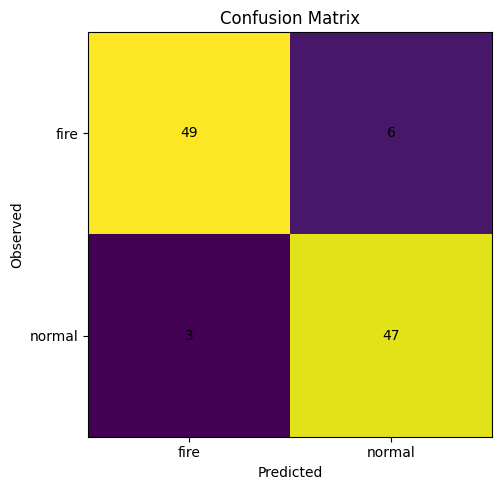

In [23]:
cm = pd.crosstab(
    pred_df["label"],
    pred_df["pred_label"],
    rownames=["Observed"],
    colnames=["Predicted"]
)

cm.to_csv(os.path.join(OUTPUT_DIR, "confusion_matrix.csv"))

plt.figure(figsize=(6, 5))
plt.imshow(cm.values)
plt.xticks(range(len(cm.columns)), cm.columns)
plt.yticks(range(len(cm.index)), cm.index)
plt.xlabel("Predicted")
plt.ylabel("Observed")
plt.title("Confusion Matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm.values[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=200)
plt.show()

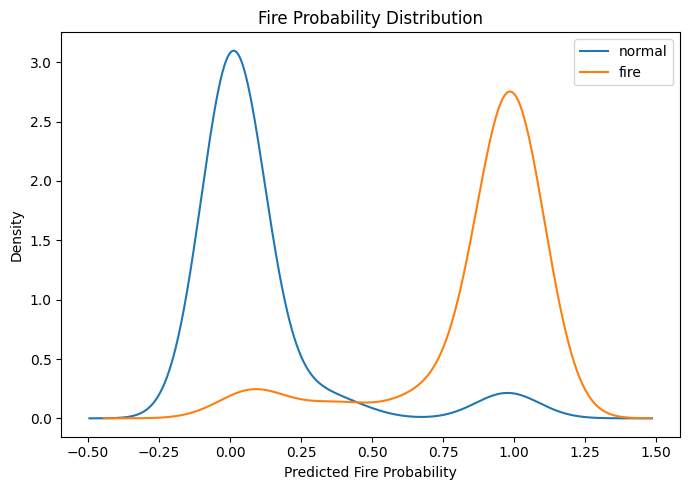

In [24]:
plt.figure(figsize=(7, 5))

for label in pred_df["label"].unique():
    pred_df[pred_df["label"] == label]["prob_fire"].plot(kind="density", label=label)

plt.xlabel("Predicted Fire Probability")
plt.title("Fire Probability Distribution")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fire_probability_distribution.png"), dpi=200)
plt.show()

In [25]:
center_lat = pred_df["lat"].mean()
center_lon = pred_df["lon"].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=6, tiles="CartoDB positron")

for _, row in pred_df.iterrows():
    color = "red" if row["pred_label"] == "fire" else "blue"
    radius = 5 + float(row["prob_fire"]) * 10
    popup = f"Observed: {row['label']}<br>Predicted: {row['pred_label']}<br>Fire probability: {row['prob_fire']:.3f}<br>Date: {row['date']}"

    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=radius,
        color=color,
        fill=True,
        fill_opacity=0.7,
        popup=popup
    ).add_to(m)

map_path = os.path.join(OUTPUT_DIR, "wildfire_prediction_map.html")
m.save(map_path)

m

In [26]:
model.save(os.path.join(MODEL_DIR, "tf_lora_wildfire_model.keras"))

with open(os.path.join(OUTPUT_DIR, "test_metrics.json"), "w") as f:
    json.dump(test_metrics, f, indent=2)

PROJECT_DIR

'/content/drive/MyDrive/wildfire_prediction/sentinel2_firms_tf_lora'